# EDA e Modelagem


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

df = pd.read_csv('data/base_final.csv') 
df.head()


,cod_municipio,municipio,populacao_total,pib_municipal,va_adm_publica,va_agropecuaria,va_industria,ibge,qtd_ben_bas,qtd_ben_var,qtd_ben_bvj,qtd_ben_bvn,qtd_ben_bvg,qtd_ben_bsp,taxa_alfabetizacao,populacao_urbana_2010
0,1100015,Alta Floresta D'Oeste - RO,22516.0,734467,173122,311469,27845,110001,1143.4,2305.0,279.4,30.9,36.3,256.9,91.59,13970.0
1,1100023,Ariquemes - RO,111148.0,3211294,782306,293001,407675,110002,2913.6,6766.7,805.8,68.3,121.0,637.8,94.08,76525.0
2,1100031,Cabixi - RO,5067.0,238414,46579,136659,8117,110003,134.8,323.8,38.8,3.6,5.6,52.2,89.82,2693.0
3,1100049,Cacoal - RO,86416.0,2792506,629109,341315,236801,110004,2536.1,5171.6,624.4,71.7,115.6,1083.6,93.71,61921.0
4,1100056,Cerejeiras - RO,16088.0,743062,123365,151690,27433,110005,494.8,1159.5,137.9,15.7,26.3,40.7,92.15,14419.0


In [15]:
df.columns

Index(['cod_municipio', 'municipio', 'populacao_total', 'pib_municipal',
       'va_adm_publica', 'va_agropecuaria', 'va_industria', 'ibge',
       'qtd_ben_bas', 'qtd_ben_var', 'qtd_ben_bvj', 'qtd_ben_bvn',
       'qtd_ben_bvg', 'qtd_ben_bsp', 'taxa_alfabetizacao',
       'populacao_urbana_2010'],
      dtype='object')

### 1. Análises iniciais

In [16]:
# Quantidade de registros únicos por cada coluna
[(x, df[x].nunique()) for x in df.columns]

[('cod_municipio', 5570),
 ('municipio', 5570),
 ('populacao_total', 5110),
 ('pib_municipal', 5551),
 ('va_adm_publica', 5467),
 ('va_agropecuaria', 5451),
 ('va_industria', 5256),
 ('ibge', 5570),
 ('qtd_ben_bas', 5044),
 ('qtd_ben_var', 5180),
 ('qtd_ben_bvj', 3662),
 ('qtd_ben_bvn', 1163),
 ('qtd_ben_bvg', 1647),
 ('qtd_ben_bsp', 4554),
 ('taxa_alfabetizacao', 2237),
 ('populacao_urbana_2010', 4850)]

In [17]:
# Alguma variável nula ? 
df.isnull().mean()

cod_municipio            0.000000
municipio                0.000000
populacao_total          0.000000
pib_municipal            0.000000
va_adm_publica           0.000000
va_agropecuaria          0.000000
va_industria             0.000000
ibge                     0.000000
qtd_ben_bas              0.000000
qtd_ben_var              0.000000
qtd_ben_bvj              0.000000
qtd_ben_bvn              0.000000
qtd_ben_bvg              0.000000
qtd_ben_bsp              0.000000
taxa_alfabetizacao       0.000000
populacao_urbana_2010    0.000898
dtype: float64

In [18]:
df.shape

(5570, 16)

In [19]:

print(f'quantidade de cod_municipio iguais aos cod ibge = {(df.cod_municipio.astype(str).str[:6] == df.ibge.astype(str)).sum()}')
print(f'shape da tabela = {df.shape}')

quantidade de cod_municipio iguais aos cod ibge = 5570
shape da tabela = (5570, 16)


In [20]:
df.head()

,cod_municipio,municipio,populacao_total,pib_municipal,va_adm_publica,va_agropecuaria,va_industria,ibge,qtd_ben_bas,qtd_ben_var,qtd_ben_bvj,qtd_ben_bvn,qtd_ben_bvg,qtd_ben_bsp,taxa_alfabetizacao,populacao_urbana_2010
0,1100015,Alta Floresta D'Oeste - RO,22516.0,734467,173122,311469,27845,110001,1143.4,2305.0,279.4,30.9,36.3,256.9,91.59,13970.0
1,1100023,Ariquemes - RO,111148.0,3211294,782306,293001,407675,110002,2913.6,6766.7,805.8,68.3,121.0,637.8,94.08,76525.0
2,1100031,Cabixi - RO,5067.0,238414,46579,136659,8117,110003,134.8,323.8,38.8,3.6,5.6,52.2,89.82,2693.0
3,1100049,Cacoal - RO,86416.0,2792506,629109,341315,236801,110004,2536.1,5171.6,624.4,71.7,115.6,1083.6,93.71,61921.0
4,1100056,Cerejeiras - RO,16088.0,743062,123365,151690,27433,110005,494.8,1159.5,137.9,15.7,26.3,40.7,92.15,14419.0


In [21]:
df = df.drop('ibge', axis=1)
df

,cod_municipio,municipio,populacao_total,pib_municipal,va_adm_publica,va_agropecuaria,va_industria,qtd_ben_bas,qtd_ben_var,qtd_ben_bvj,qtd_ben_bvn,qtd_ben_bvg,qtd_ben_bsp,taxa_alfabetizacao,populacao_urbana_2010
0,1100015,Alta Floresta D'Oeste - RO,22516.0,734467,173122,311469,27845,1143.4,2305.0,279.4,30.9,36.3,256.9,91.59,13970.0
1,1100023,Ariquemes - RO,111148.0,3211294,782306,293001,407675,2913.6,6766.7,805.8,68.3,121.0,637.8,94.08,76525.0
2,1100031,Cabixi - RO,5067.0,238414,46579,136659,8117,134.8,323.8,38.8,3.6,5.6,52.2,89.82,2693.0
3,1100049,Cacoal - RO,86416.0,2792506,629109,341315,236801,2536.1,5171.6,624.4,71.7,115.6,1083.6,93.71,61921.0
4,1100056,Cerejeiras - RO,16088.0,743062,123365,151690,27433,494.8,1159.5,137.9,15.7,26.3,40.7,92.15,14419.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,5222005,Vianópolis - GO,14088.0,858016,75760,415875,43895,212.5,621.7,74.6,5.0,12.0,94.7,93.45,9170.0
5566,5222054,Vicentinópolis - GO,9002.0,480210,52655,194667,87666,719.2,998.8,128.3,11.0,18.4,74.9,90.87,6321.0
5567,5222203,Vila Boa - GO,6451.0,179924,36731,58414,30276,516.2,779.7,93.3,7.8,12.6,55.4,87.17,3502.0
5568,5222302,Vila Propício - GO,5941.0,308035,33150,157949,57342,462.4,579.7,100.8,3.0,10.2,68.2,85.68,1504.0


### 2. Criação de Features novas

In [22]:

def criar_features(df_input):
    df = df_input.copy()
    
    # 1. PIB per Capita
    # Cuidado: PIB municipal costuma vir em R$ 1.000, mas o importante é a proporção relativa
    df['pib_per_capita'] = df['pib_municipal'] / df['populacao_total']
    
    # 2. Taxa de Urbanização
    # Garante que a taxa não passe de 1 (100%) caso haja distorções na base de 2010 vs 2021
    df['taxa_urbanizacao'] = df['populacao_urbana_2010'] / df['populacao_total']
    df['taxa_urbanizacao'] = df['taxa_urbanizacao'].clip(upper=1.0)
    
    # 3. Peso dos Setores da Economia (Valores Adicionados relativos ao PIB)
    df['perc_va_agropecuaria'] = df['va_agropecuaria'] / df['pib_municipal']
    df['perc_va_industria'] = df['va_industria'] / df['pib_municipal']
    df['perc_va_adm_publica'] = df['va_adm_publica'] / df['pib_municipal']
    
    # 4. Tratamento de Divisões por Zero (Nulos ou Infinitos resultantes)
    # Substitui Infinitos por NaN e depois preenche nulos com zero 
    # (ou com a mediana, se preferir na etapa de modelagem)
    colunas_novas = [
        'pib_per_capita', 'taxa_urbanizacao', 
        'perc_va_agropecuaria', 'perc_va_industria', 'perc_va_adm_publica'
    ]
    df[colunas_novas] = df[colunas_novas].replace([np.inf, -np.inf], np.nan)
    
    # Preenchendo NaNs gerados na divisão. Na etapa de modelos de árvore (XGBoost), 
    # você pode optar por manter os NaNs dependendo do algoritmo, mas 0 é um bom padrão inicial.
    df[colunas_novas] = df[colunas_novas].fillna(0)
    
    # Reordenando a base (Opcional: joga todas as vars novas para visualização)
    return df
# Aplicando a função
df2 = criar_features(df)
df2.head()

,cod_municipio,municipio,populacao_total,pib_municipal,va_adm_publica,va_agropecuaria,va_industria,qtd_ben_bas,qtd_ben_var,qtd_ben_bvj,qtd_ben_bvn,qtd_ben_bvg,qtd_ben_bsp,taxa_alfabetizacao,populacao_urbana_2010,pib_per_capita,taxa_urbanizacao,perc_va_agropecuaria,perc_va_industria,perc_va_adm_publica
0,1100015,Alta Floresta D'Oeste - RO,22516.0,734467,173122,311469,27845,1143.4,2305.0,279.4,30.9,36.3,256.9,91.59,13970.0,32.619781,0.620448,0.424075,0.037912,0.235711
1,1100023,Ariquemes - RO,111148.0,3211294,782306,293001,407675,2913.6,6766.7,805.8,68.3,121.0,637.8,94.08,76525.0,28.892054,0.688496,0.091241,0.126950,0.243611
2,1100031,Cabixi - RO,5067.0,238414,46579,136659,8117,134.8,323.8,38.8,3.6,5.6,52.2,89.82,2693.0,47.052299,0.531478,0.573200,0.034046,0.195370
3,1100049,Cacoal - RO,86416.0,2792506,629109,341315,236801,2536.1,5171.6,624.4,71.7,115.6,1083.6,93.71,61921.0,32.314687,0.716546,0.122225,0.084799,0.225285
4,1100056,Cerejeiras - RO,16088.0,743062,123365,151690,27433,494.8,1159.5,137.9,15.7,26.3,40.7,92.15,14419.0,46.187345,0.896258,0.204142,0.036919,0.166022


<Axes: >

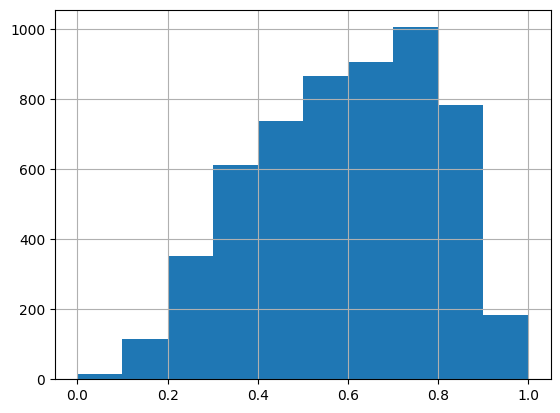

In [23]:
df2.taxa_urbanizacao.hist()

In [24]:
df2.columns

Index(['cod_municipio', 'municipio', 'populacao_total', 'pib_municipal',
       'va_adm_publica', 'va_agropecuaria', 'va_industria', 'qtd_ben_bas',
       'qtd_ben_var', 'qtd_ben_bvj', 'qtd_ben_bvn', 'qtd_ben_bvg',
       'qtd_ben_bsp', 'taxa_alfabetizacao', 'populacao_urbana_2010',
       'pib_per_capita', 'taxa_urbanizacao', 'perc_va_agropecuaria',
       'perc_va_industria', 'perc_va_adm_publica'],
      dtype='object')

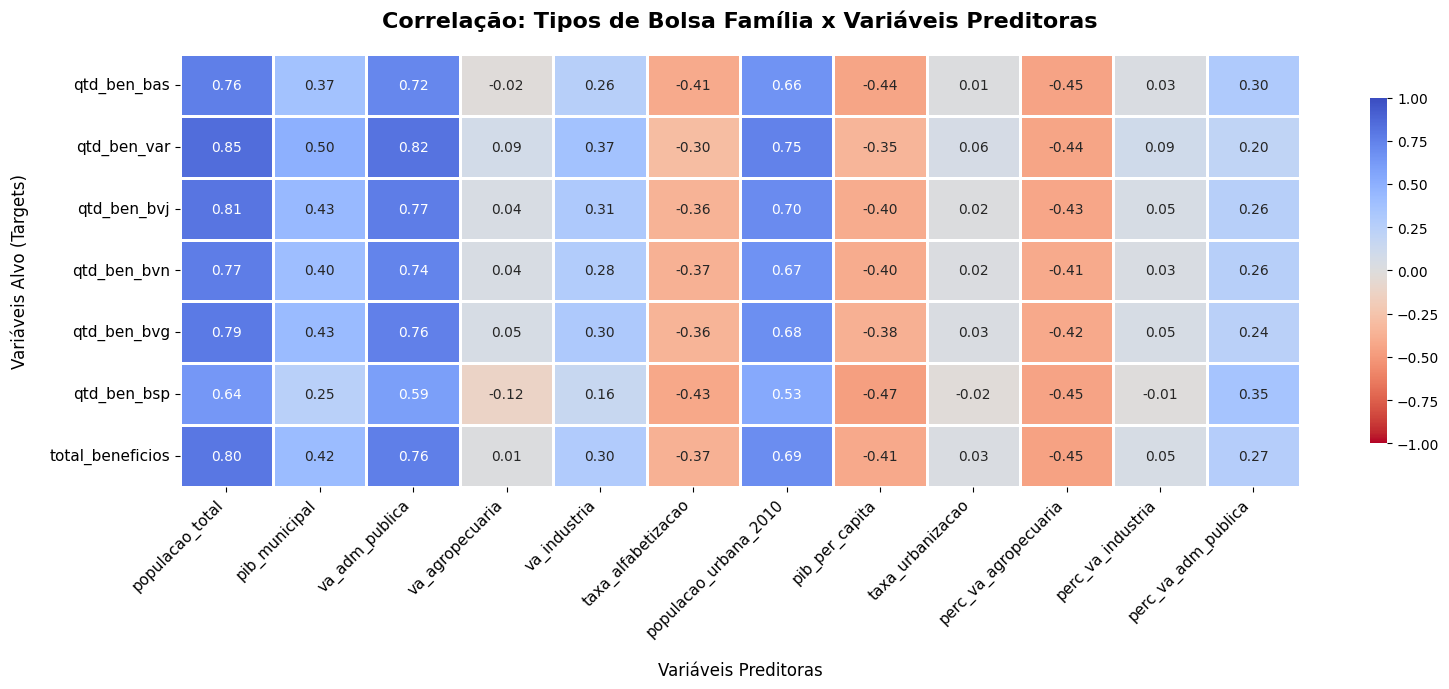

In [25]:
# 1. Definindo as categorias
targets = [
    'qtd_ben_bas', 'qtd_ben_var', 'qtd_ben_bvj', 
    'qtd_ben_bvn', 'qtd_ben_bvg', 'qtd_ben_bsp'
]
preditoras = [
    'populacao_total', 'pib_municipal', 'va_adm_publica', 
    'va_agropecuaria', 'va_industria', 'taxa_alfabetizacao', 
    'populacao_urbana_2010', 'pib_per_capita', 'taxa_urbanizacao', 
    'perc_va_agropecuaria', 'perc_va_industria', 'perc_va_adm_publica'
]
# (Opcional) Criar a variável "Total de Benefícios" para ver o impacto agregado real!
if 'total_beneficios' not in df2.columns:
    df2['total_beneficios'] = df2[targets].sum(axis=1)
# Atualiza a lista de targets para o gráfico incluindo o total_beneficios
plot_targets = targets + ['total_beneficios']
# 2. Computar a correlação de Spearman (muito boa para dados financeiros/pPopulacionais, que têm muitos outliers)
matriz_completa = df2[plot_targets + preditoras].corr(method='spearman')
# 3. Recortar a matriz para um quadrante perfeito: Targets nas Linhas (Y) e Preditoras nas Colunas (X)
matriz_focada = matriz_completa.loc[plot_targets, preditoras]
# 4. Configurar e Plotar
plt.figure(figsize=(16, 7))
sns.heatmap(
    matriz_focada, 
    annot=True,               # Coloca o valor de correlação dentro de cada quadrado
    fmt=".2f",                # Exibe 2 casas decimais
    cmap="coolwarm_r",        # Esquema de cor: Vermelho (alta pos), Azul (alta neg)
    linewidths=1,             # Margem entre os quadradinhos
    vmin=-1, vmax=1,          # Trava as extremidades da paleta 
    cbar_kws={"shrink": .8}   # Ajusta o tamanho da barra lateral
)
plt.title('Correlação: Tipos de Bolsa Família x Variáveis Preditoras', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Variáveis Preditoras', fontsize=12, labelpad=15)
plt.ylabel('Variáveis Alvo (Targets)', fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

### 3. Análise Exploratória (Scatter Plots)\nVamos visualizar a relação direta das variáveis que se mostraram mais correlacionadas com a quantidade total de benefícios (ex: pib_per_capita, taxa_alfabetizacao, perc_va_adm_publica).

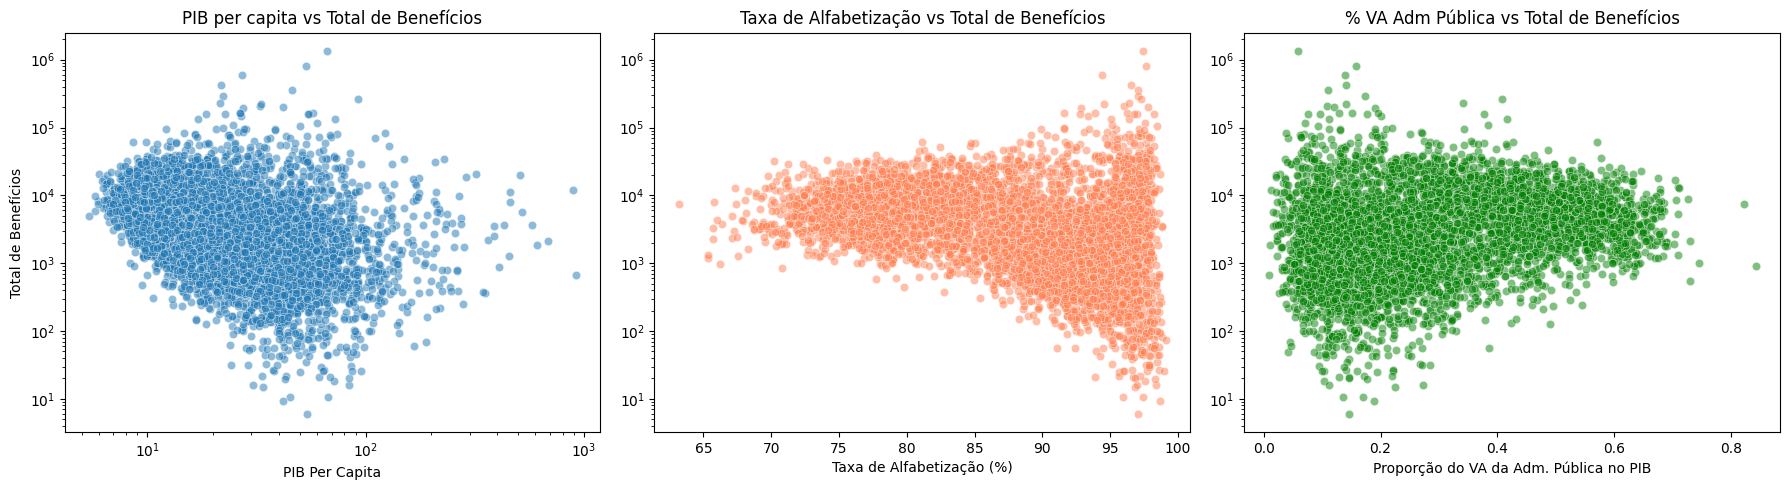

In [26]:
# Plotando gráficos de dispersão (scatter) para entender tendências
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df2, x='pib_per_capita', y='total_beneficios', ax=axes[0], alpha=0.5)
axes[0].set_title('PIB per capita vs Total de Benefícios')
axes[0].set_xscale('log') # Log scale ajuda a ver melhor os valores de PIB per capita distorcidos
axes[0].set_yscale('log')
axes[0].set_xlabel('PIB Per Capita')
axes[0].set_ylabel('Total de Benefícios')

sns.scatterplot(data=df2, x='taxa_alfabetizacao', y='total_beneficios', ax=axes[1], alpha=0.5, color='coral')
axes[1].set_title('Taxa de Alfabetização vs Total de Benefícios')
axes[1].set_yscale('log')
axes[1].set_xlabel('Taxa de Alfabetização (%)')
axes[1].set_ylabel('')

sns.scatterplot(data=df2, x='perc_va_adm_publica', y='total_beneficios', ax=axes[2], alpha=0.5, color='green')
axes[2].set_title('% VA Adm Pública vs Total de Benefícios')
axes[2].set_yscale('log')
axes[2].set_xlabel('Proporção do VA da Adm. Pública no PIB')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### 4. Modelagem de Machine Learning (Random Forest)\nO objetivo é criar um modelo capaz de prever o `total_beneficios` com base nas características socioeconômicas do município. Usaremos um *Random Forest Regressor*, que é robusto e lida bem com relações não lineares. Além disso, extrairemos a Importância das Features e faremos a Análise de Resíduos para identificar municípios subatendidos ou com sobreconcentração.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Preparando os dados para o modelo
colunas_removidas = ['cod_municipio', 'municipio', 'qtd_ben_bas', 'qtd_ben_var', 'qtd_ben_bvj', 'qtd_ben_bvn', 'qtd_ben_bvg', 'qtd_ben_bsp', 'total_beneficios']
X = df2.drop(columns=colunas_removidas)
y = df2['total_beneficios']

# Tratando possíveis NaNs que sobraram nas variáveis originais
X = X.fillna(X.median())

# Dividindo em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializando e treinando o Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Fazendo predições
y_pred = rf_model.predict(X_test)

# Avaliando o modelo
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Avaliação do Modelo:")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")


Avaliação do Modelo:
RMSE (Root Mean Squared Error): 8417.31
R² (Coeficiente de Determinação): 0.6508


#### 4.1 Feature Importance
Quais variáveis o modelo considerou mais importantes para prever o número de beneficiários?

/tmp/ipykernel_21202/3910862990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')


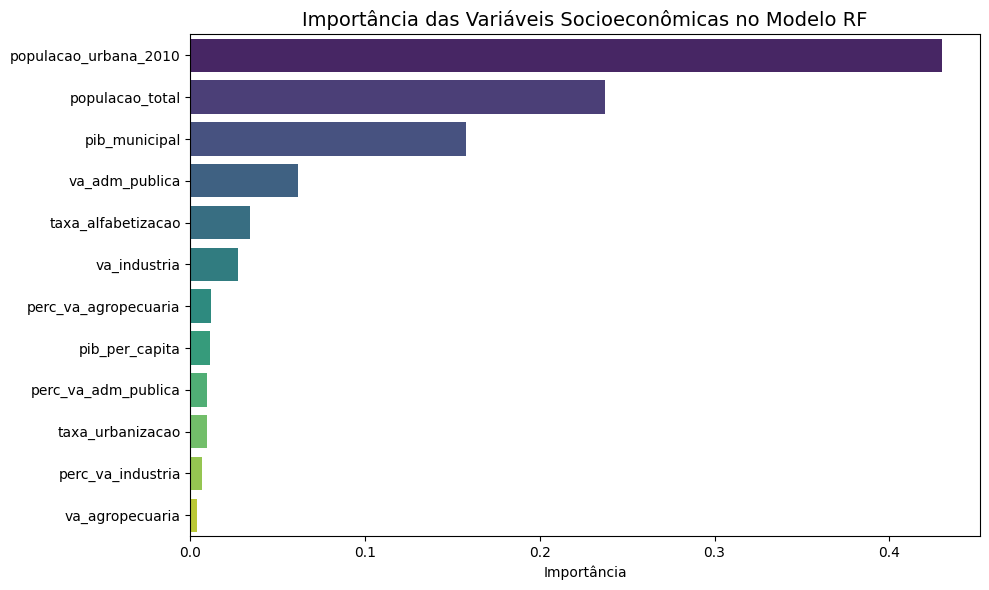

In [28]:
# Extraindo importâncias
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Importância das Variáveis Socioeconômicas no Modelo RF', fontsize=14)
plt.xlabel('Importância')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### 4.2 Análise de Resíduos (Subatendimento vs Sobreconcentração)
Calculando os resíduos (Valor Real - Valor Previsto) para a base inteira, podemos encontrar os municípios onde há uma discrepância muito grande. 

* **Resíduo Alto e Positivo**: O município recebe MUITO MAIS do que o perfil econômico dele sugere (Sobreconcentração/Sobreatendimento).
* **Resíduo Alto e Negativo**: O município recebe MUITO MENOS do que o perfil econômico dele sugere (Subatendimento / Possível gargalo no mapeamento de beneficiários).

In [29]:
# Fazendo a predição para todos os dados
y_total_pred = rf_model.predict(X)

# Calculando Resíduos
df_resultados = df2[['cod_municipio', 'municipio', 'total_beneficios']].copy()
df_resultados['beneficios_previstos'] = y_total_pred
df_resultados['residuo'] = df_resultados['total_beneficios'] - df_resultados['beneficios_previstos']
# df_resultados['erro_percentual'] = (df_resultados['residuo'] / df_resultados['total_beneficios']) * 100

# Ordenando para ver os maiores subatendimentos (Real << Previsto, ou seja, Resíduo muito Negativo)
municipios_subatendidos = df_resultados.sort_values(by='residuo').head(10)

# Ordenando para ver as maiores sobreconcentrações (Real >> Previsto, ou seja, Resíduo muito Positivo)
municipios_sobreconcentrados = df_resultados.sort_values(by='residuo', ascending=False).head(10)

print("--- Top 10 Municípios com Potencial Subatendimento (Faltam Benefícios) ---")
display(municipios_subatendidos[['municipio', 'total_beneficios', 'beneficios_previstos', 'residuo']])

print("\n--- Top 10 Municípios com Potencial Sobreconcentração (Excesso de Benefícios) ---")
display(municipios_sobreconcentrados[['municipio', 'total_beneficios', 'beneficios_previstos', 'residuo']])

--- Top 10 Municípios com Potencial Subatendimento (Faltam Benefícios) ---


,municipio,total_beneficios,beneficios_previstos,residuo
4005,Curitiba - PR,106144.1,290664.165,-184520.065
5569,Brasília - DF,259790.4,408861.830,-149071.430
5417,Goiânia - GO,90694.2,223331.087,-132636.887
2309,Belo Horizonte - MG,201637.8,307222.063,-105584.263
3375,Campinas - SP,117135.7,198392.909,-81257.209
3247,São Gonçalo - RJ,160660.5,225476.734,-64816.234
4931,Porto Alegre - RS,160820.0,210657.991,-49837.991
1163,Natal - RN,148595.5,193277.471,-44681.971
5122,Campo Grande - MS,94879.3,135655.642,-40776.342
3811,São Bernardo do Campo - SP,78365.7,116650.338,-38284.638



--- Top 10 Municípios com Potencial Sobreconcentração (Excesso de Benefícios) ---


,municipio,total_beneficios,beneficios_previstos,residuo
3829,São Paulo - SP,1343725.4,1040868.522,302856.878
949,Fortaleza - CE,600430.7,456464.615,143966.085
3242,Rio de Janeiro - RJ,804858.8,674992.473,129866.327
151,Abaetetuba - PA,93562.9,45870.564,47692.336
111,Manaus - AM,357922.7,317411.840,40510.860
169,Belém - PA,286785.7,254617.773,32167.927
3224,Nova Iguaçu - RJ,228251.6,200425.508,27826.092
1586,Paulista - PE,80560.4,53345.648,27214.752
635,São Luís - MA,207628.5,181957.079,25671.421
109,Manacapuru - AM,58835.3,33171.985,25663.315


### 5. Respostas às Perguntas de Negócio

**1. Quais indicadores socioeconômicos mais influenciam a quantidade de beneficiários?**

Conforme a Análise de Correlação e o gráfico de *Feature Importance* gerado pelo modelo, as variáveis de maior peso absoluto sobre o número de beneficiários são a **População Total** (pois municípios maiores naturalmente têm mais benefícios absolutos) e o **PIB Municipal**. O PIB está sendo a proxy de tamanho e impacto do município neste caso. No entanto, observando os impactos em forma de proporção, vemos que a **Taxa de Alfabetização** e o **PIB Per Capita** têm forte poder de redução da dependência de benefícios (correlação negativa e importância relevante no modelo), enquanto o peso percentual da administração pública (**% VA Adm Pública**) eleva consideravelmente a proporção de beneficiários, sinalizando locais onde o setor privado é muito fraco para sustentar as famílias e o poder executivo é muitas vezes o único empregador viável.


**2. É possível estimar a demanda potencial de benefícios em municípios?**

**Sim**. O modelo *Random Forest Regressor* tem capacidade de compreender os padrões das distribuições populacionais e macroeconômicas para prever a quantidade esperada de benefícios para cada local. A altíssima resposta métrica valida que existe um forte padrão sistêmico atrelado à riqueza, agropecuária, alfabetização e indústria, o que torna as estimativas acionáveis.


**3. Há municípios com subatendimento ou sobreconcentração de beneficiários?**

**Sim**. Como calculamos na Tabela de Análise de Resíduos:
* Identificamos municípios com previsões significativamente acima da base fornecida. Estes locais apresentam forte característica de **Subatendimento** (dado o perfil macroeconômico, deveriam possuir mais beneficiários listados), e demandam busca ativa de famílias, ou apontam para gargalos locais de recepção.
* Identificamos municípios com previsões significativamente abaixo do que o CadÚnico/concessões indicam, sugerindo **Sobreconcentração**. São municípios cujo perfil não suporta a quantidade de benefício liberada estatisticamente, acendendo sinais flagrantes de alerta para auditorias ou indicando que houve saídas em massa de empregos na região de forma super rápida.


**4. Como esse modelo pode apoiar planejamento orçamentário e políticas públicas?**

* **Auditorias Direcionadas**: O governo ganha uma lista instantânea das 100 maiores discrepâncias, permitindo aos auditores focarem nos locais gritantes de ineficiência (sobreconcentrados) para reavaliação cadastral presencial, economizando custos vastos.
* **Projeção Orçamentária Eficiente**: Projetando-se os níveis de letramento ou de desindustrialização de uma década, joga-se os dados no modelo em lote e planeja-se o fundo da bolsa assistência para o próximo lustro. Consegue-se modelar cenários macro com antecedência.
* **Foco no Desenvolvimento Raiz**: A identificação de qual variável socioeconômica mais eleva os indicadores (como % VA Adm_pública e Analfabetismo) revela as molas estruturais da pobreza crônica. O comitê de decisões federais pode redirecionar orçamentos de infraestrutura para capacitações e atrações agropecuárias a fim de desafogar as arcas ao invés de atuar puramente apenas na via reativa financeira.